# CS436 Computer Vision Project - Week 1 Deliverable


**Student:** Muhammad Zain Naseer , Kousar Pervaiz



In [228]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from itertools import product
from PIL import Image
from PIL.ExifTags import TAGS
import open3d as o3d

from scipy.optimize import least_squares
from collections import defaultdict
import pickle
import os


plt.rcParams['figure.figsize'] = (12, 10)


## 1. Load Image Dataset



In [229]:

IMAGE_DIR = r"images-2"  


image_paths = sorted(glob.glob(f"{IMAGE_DIR}/*.jpg"))

print(f"{len(image_paths)} images")

32 images


In [230]:

images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  
    else:
        print(f"Warning: Could not load {path}")

print(f"Loaded {len(images)} images successfully")
if len(images) > 0:
    print(f"Image shape: {images[0].shape}")

Loaded 32 images successfully
Image shape: (8160, 6120, 3)


## 2. Display Image Grid (10 Images)

Displaying a grid of 10 images from the dataset to show the variety of viewpoints.

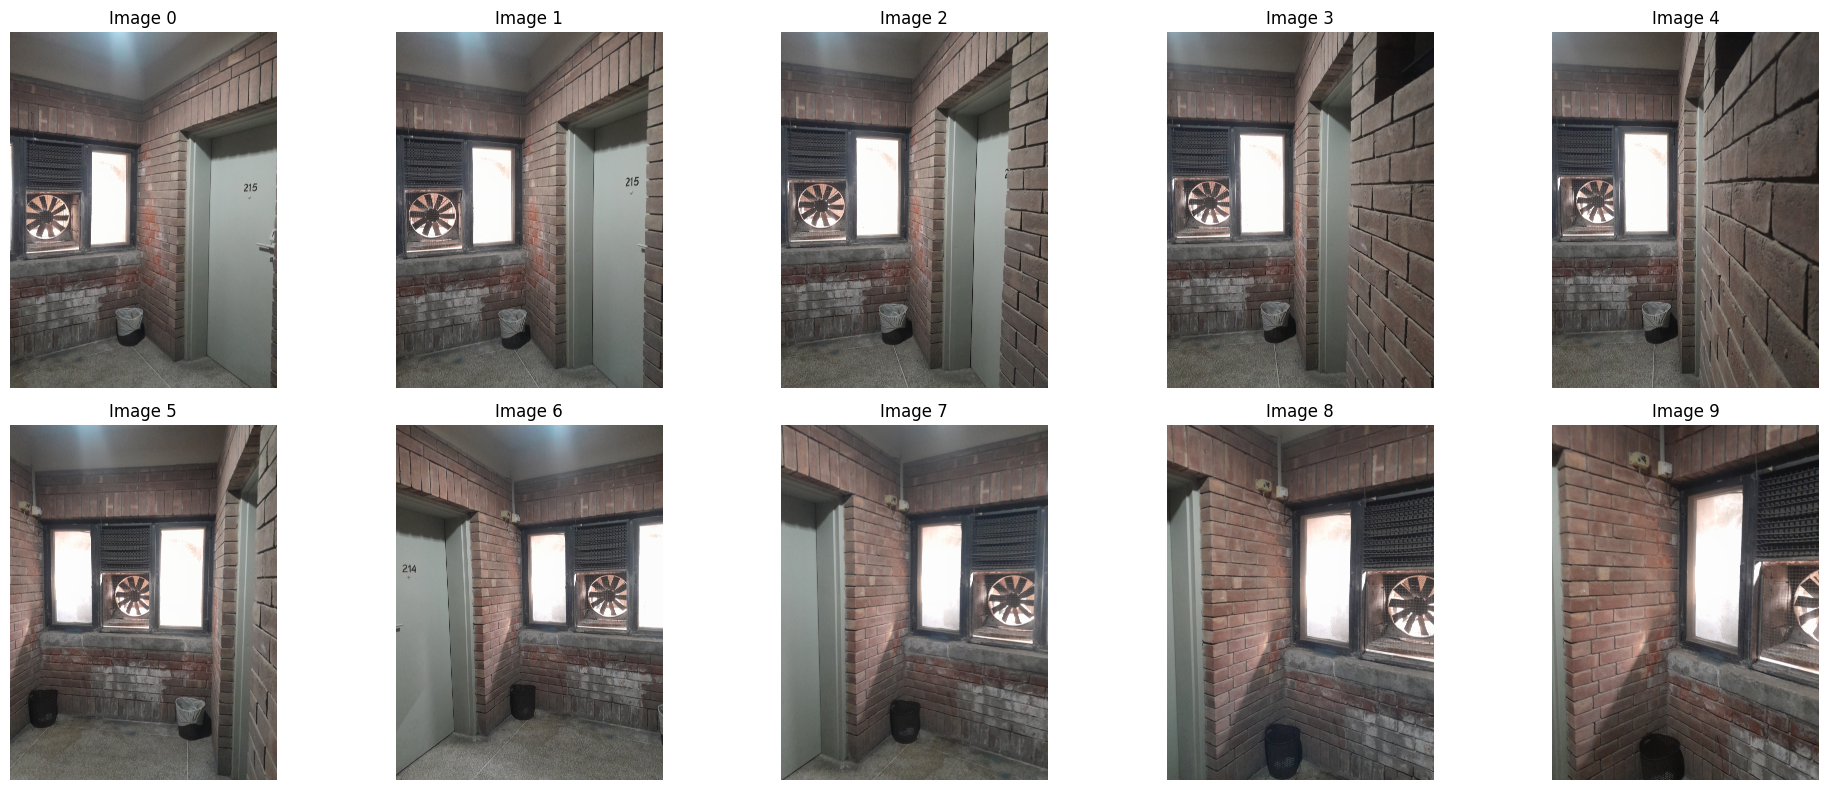

In [231]:
def display_image_grid(images, n_images, cols):

    n_images = min(n_images, len(images))
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten() if n_images > 1 else [axes]
    
    for i in range(n_images):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Image {i}', fontsize=12)
        axes[i].axis('off')
    

    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

display_image_grid(images, n_images=10, cols=5)

## 3. Image Preprocessing



In [232]:
def preprocess_image(img, target_width=1920, convert_to_gray=True):

    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    

    h, w = img_bgr.shape[:2]
    if w > target_width:
        scale = target_width / w
        new_w = int(w * scale)
        new_h = int(h * scale)
        img_bgr = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    

    

    if convert_to_gray:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
     
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


if len(images) > 0:
    sample_img = images[0]
    print(f"Original image shape: {sample_img.shape}")
    

    preprocessed_images = []
    for img in images:
        preprocessed = preprocess_image(img, convert_to_gray=True)
        preprocessed_images.append(preprocessed)
    
    print(f"Preprocessed {len(preprocessed_images)} images")
    print(f"Preprocessed image shape: {preprocessed_images[0].shape}")
    print(f"Image is now grayscale: {len(preprocessed_images[0].shape) == 2}")
else:
    preprocessed_images = images
    print("No preprocessing applied (using original images)")

Original image shape: (8160, 6120, 3)
Preprocessed 32 images
Preprocessed image shape: (2560, 1920)
Image is now grayscale: True


## 4. Feature Detection and Matching

Using SIFT (Scale-Invariant Feature Transform) to detect and match features between consecutive images.

### 4.1 Feature Detection Setup

In [233]:

sift = cv2.SIFT_create(nfeatures=25000)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

print("Feature detector and matcher initialized")

Feature detector and matcher initialized


### 4.2 Detect Features in All Images

In [234]:

keypoints_list = []
descriptors_list = []
images_color = []  

for i, img in enumerate(preprocessed_images):
    kp, desc = sift.detectAndCompute(img, None)
    keypoints_list.append(kp)
    descriptors_list.append(desc)
    
    
    img_color = preprocess_image(images[i], convert_to_gray=False)
    images_color.append(img_color)

print(f"\nTotal images processed: {len(keypoints_list)}")
print(f"Color images stored: {len(images_color)}")


Total images processed: 32
Color images stored: 32


### 4.3 Visualize Keypoints on Sample Image

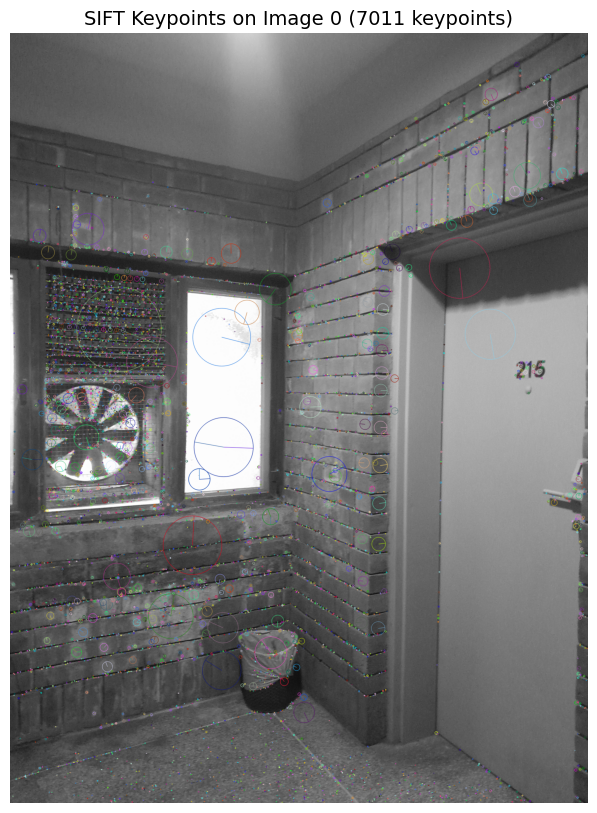

In [235]:

img_with_kp = cv2.drawKeypoints(
    cv2.cvtColor(preprocessed_images[0], cv2.COLOR_RGB2BGR),
    keypoints_list[0],
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Keypoints on Image 0 ({len(keypoints_list[0])} keypoints)', fontsize=14)
plt.axis('off')
plt.show()

## 5. Feature Matching Between Consecutive Images

Matching features between 4-5 consecutive image pairs using Lowe's ratio test.

In [236]:
def match_features(desc1, desc2, ratio_thresh=0.7):

    matches = flann.knnMatch(desc1, desc2, k=2)
    
    
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    
    return good_matches

def visualize_matches(img1, kp1, img2, kp2, matches, title=""):
    
    
    img1_bgr = cv2.cvtColor(img1, cv2.COLOR_RGB2BGR)
    img2_bgr = cv2.cvtColor(img2, cv2.COLOR_RGB2BGR)
    
    
    img_matches = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2, matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=14)
    plt.axis('off')
    return img_matches

### 5.1 Match Features Between 4-5 Consecutive Image Pairs

Matching features between 5 consecutive image pairs


--- Matching Image 0 and Image 1 ---
Found 599 good matches


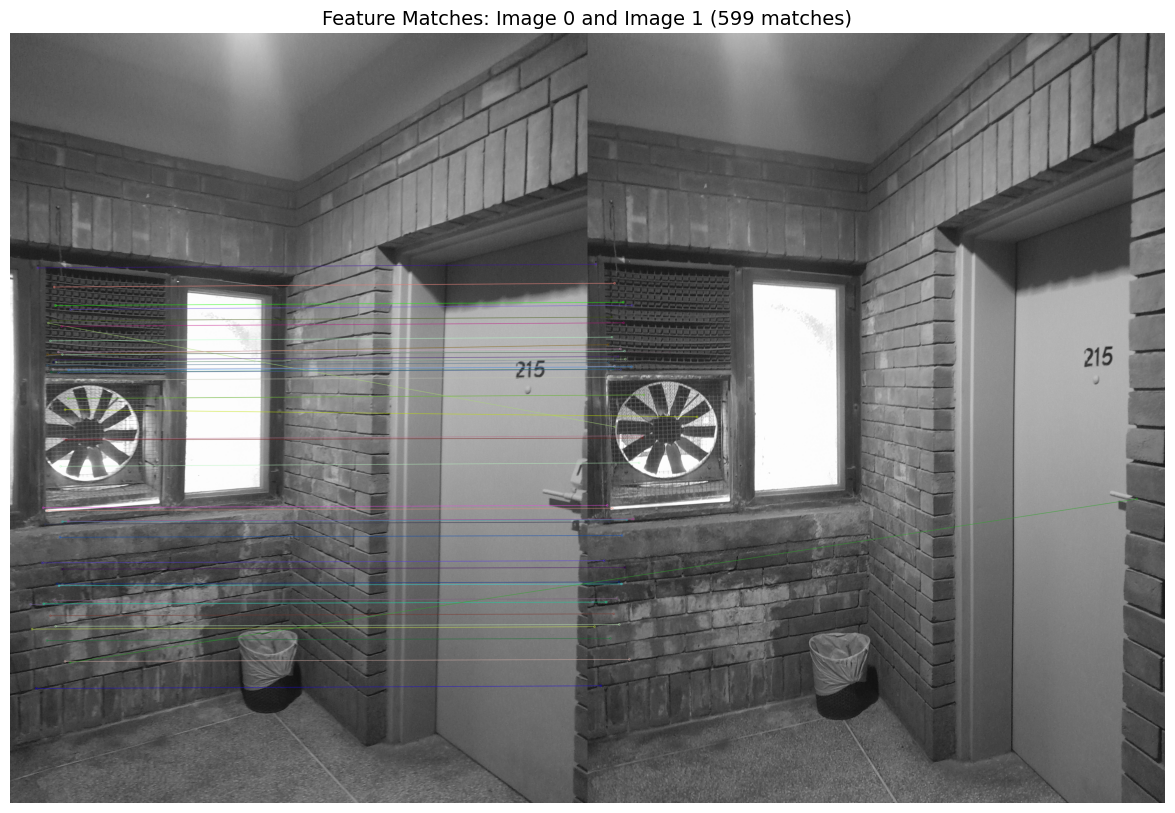


--- Matching Image 1 and Image 2 ---
Found 904 good matches


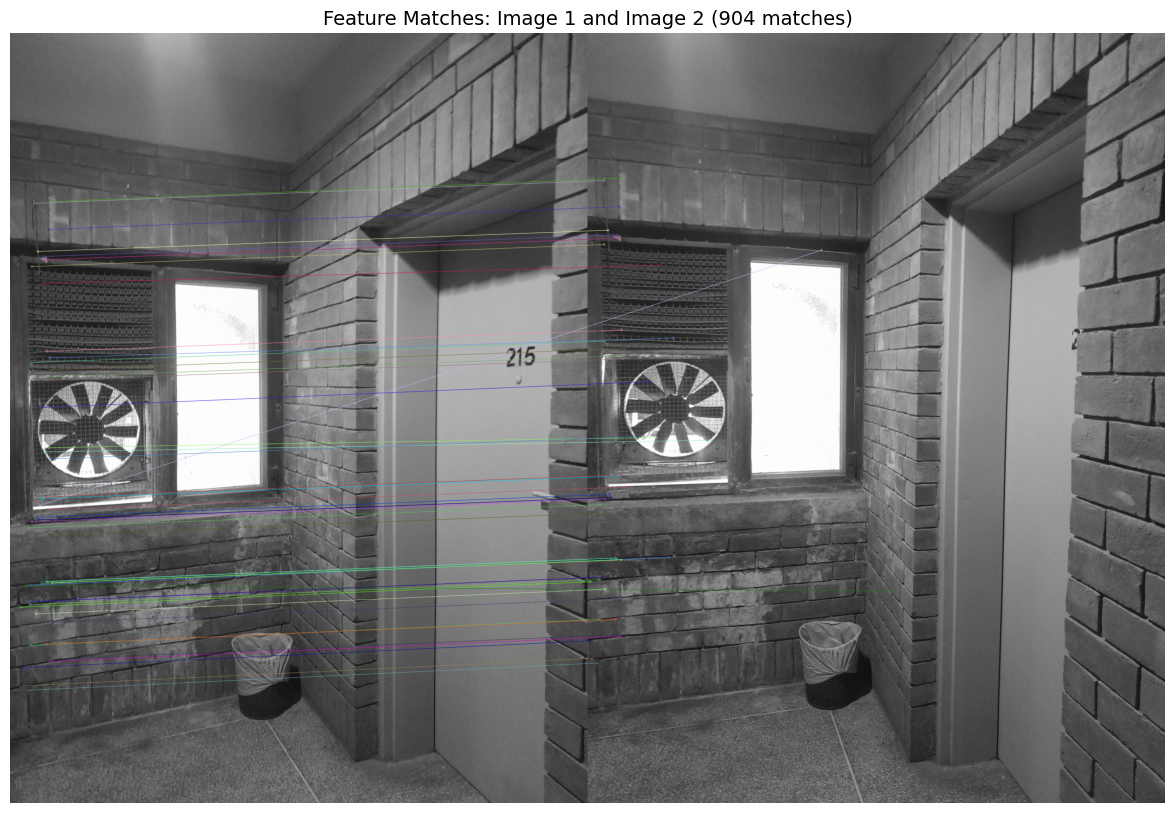


--- Matching Image 2 and Image 3 ---
Found 740 good matches


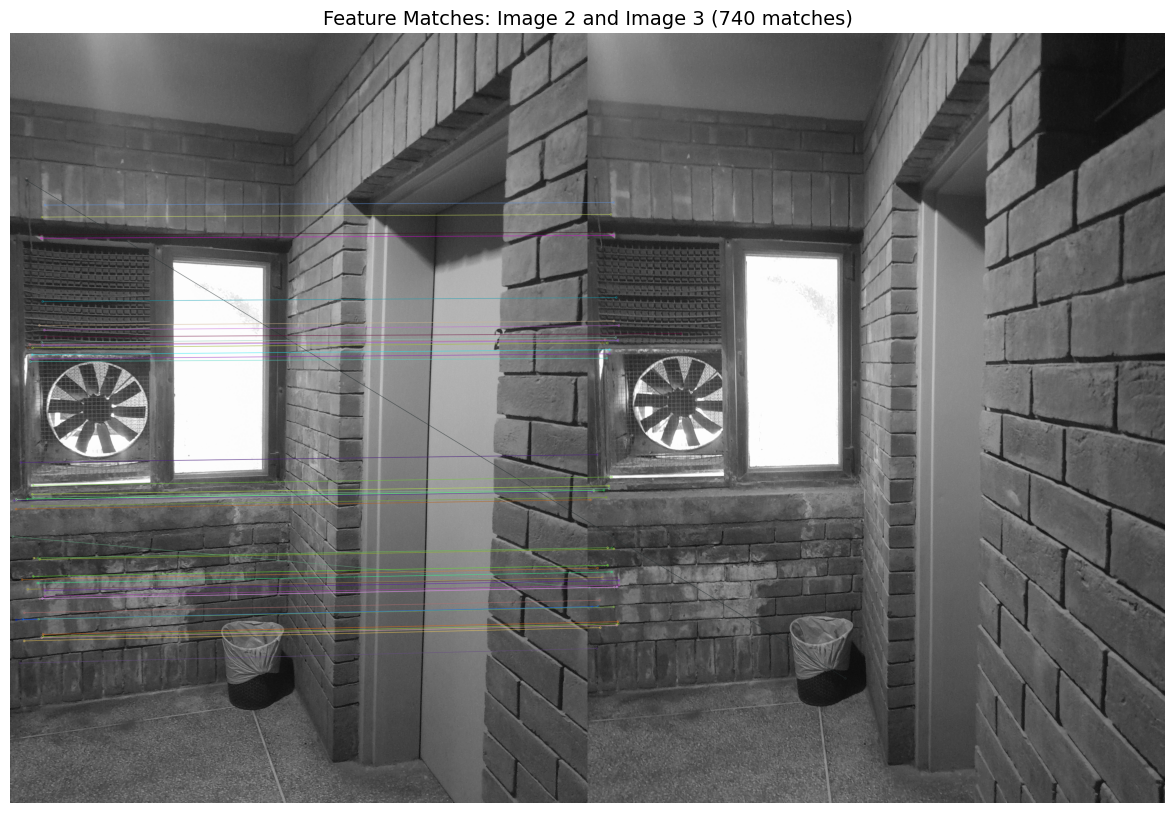


--- Matching Image 3 and Image 4 ---
Found 1027 good matches


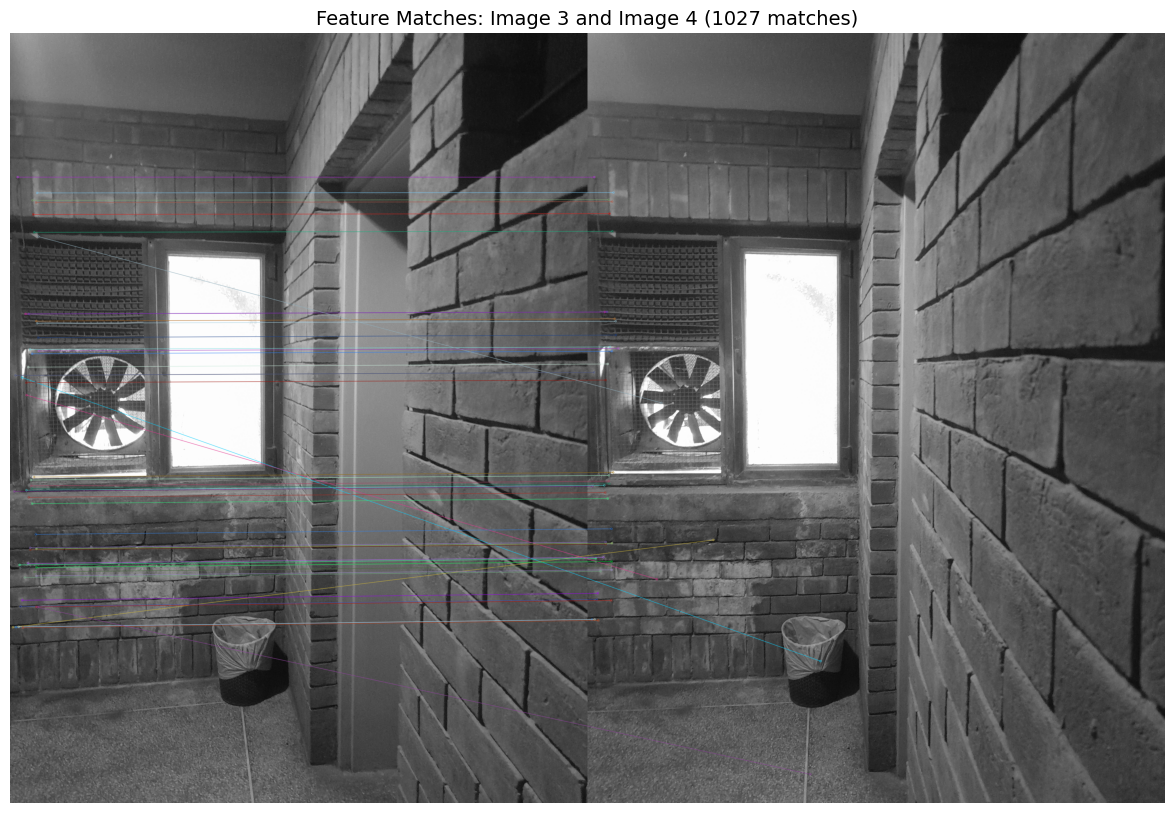


--- Matching Image 4 and Image 5 ---
Found 876 good matches


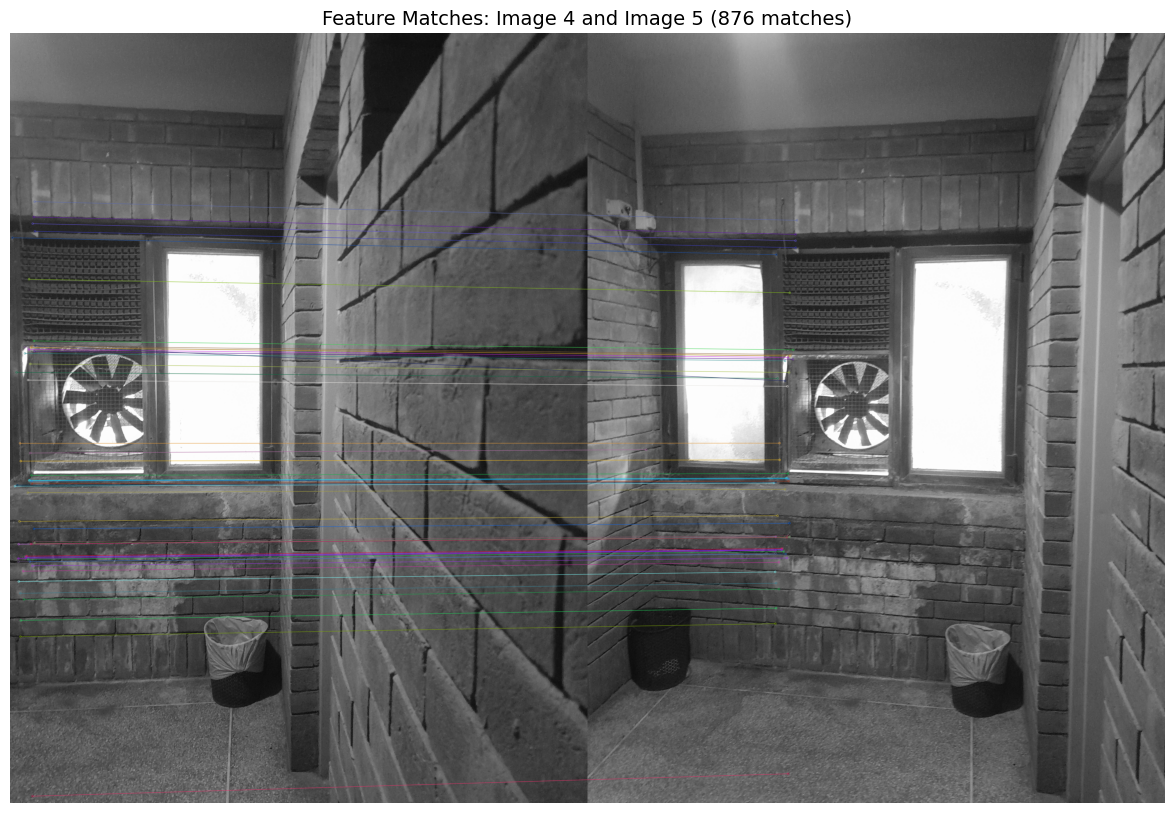

In [237]:

n_pairs = min(5, len(preprocessed_images) - 1)

print(f"Matching features between {n_pairs} consecutive image pairs\n")

for i in range(n_pairs):
    print(f"\n--- Matching Image {i} and Image {i+1} ---")
    
    
    matches = match_features(descriptors_list[i], descriptors_list[i+1])
    
    print(f"Found {len(matches)} good matches")
    
    
    title = f'Feature Matches: Image {i} and Image {i+1} ({len(matches)} matches)'
    visualize_matches(
        preprocessed_images[i], keypoints_list[i],
        preprocessed_images[i+1], keypoints_list[i+1],
        matches, title
    )
    
    

    plt.show()

---

# Week 2: Two-View Reconstruction



In [238]:


img1_gray = preprocessed_images[0]
img2_gray = preprocessed_images[1]
img1_color = images_color[0]
img2_color = images_color[1]

kp1 = keypoints_list[0]
kp2 = keypoints_list[1]
desc1 = descriptors_list[0]
desc2 = descriptors_list[1]

print(f"\nUsing Image 0 and Image 1 for reconstruction")
print(f"Image 1: {len(kp1)} keypoints")
print(f"Image 2: {len(kp2)} keypoints")


matches = match_features(desc1, desc2, ratio_thresh=0.75)
print(f"Found {len(matches)} matches")


Using Image 0 and Image 1 for reconstruction
Image 1: 7011 keypoints
Image 2: 10190 keypoints
Found 758 matches


In [239]:

def get_camera_intrinsics_from_exif(image_path, img_shape):

    img = Image.open(image_path)
    exif = img._getexif()
    
    if exif is None:
        print("No EXIF data found, using estimation")
        return estimate_camera_intrinsics(img_shape)
    
    
    exif_data = {}
    for tag_id, value in exif.items():
        tag = TAGS.get(tag_id, tag_id)
        exif_data[tag] = value
    
    
    focal_length_mm = float(exif_data.get('FocalLength', 0))
    focal_length_35mm = exif_data.get('FocalLengthIn35mmFilm', 0)
    
    
    orig_width = exif_data.get('ExifImageWidth', img_shape[1])
    orig_height = exif_data.get('ExifImageHeight', img_shape[0])
    
    print(f"Camera: {exif_data.get('Make', 'Unknown')} {exif_data.get('Model', 'Unknown')}")
    print(f"Focal length: {focal_length_mm}mm (35mm equivalent: {focal_length_35mm}mm)")
    print(f"Original image size: {orig_width}x{orig_height}")
    
    
    
    
    if focal_length_35mm > 0:
        
        focal_pixels = (focal_length_35mm / 36.0) * orig_width
    else:
        
        sensor_width_mm = 6.17  
        focal_pixels = (focal_length_mm / sensor_width_mm) * orig_width
    
    
    scale = img_shape[1] / orig_width
    focal_scaled = focal_pixels * scale
    
    
    cx = img_shape[1] / 2.0
    cy = img_shape[0] / 2.0
    
    
    K = np.array([
        [focal_scaled, 0, cx],
        [0, focal_scaled, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    
    return K


def estimate_camera_intrinsics(img_shape):
 
    h, w = img_shape[:2]
    focal_length = max(w, h) * 1.2
    cx = w / 2.0
    cy = h / 2.0
    
    K = np.array([
        [focal_length, 0, cx],
        [0, focal_length, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    
    return K


def filter_points(points_3d, pts1, pts2, R, t, K, max_reproj_error=5.0, max_depth=100.0):
    """Filter 3D points based on validity checks - RELAXED VERSION"""
    valid_mask = np.ones(len(points_3d), dtype=bool)
    
    
    depths1 = points_3d[:, 2]   
    valid_mask &= depths1 > 0
    
    
    points_cam2 = (R @ points_3d.T + t).T
    depths2 = points_cam2[:, 2]
    valid_mask &= depths2 > 0
    
    
    valid_mask &= depths1 < max_depth * 2  
    valid_mask &= depths2 < max_depth * 2
    
    
    points_2d_proj = (K @ points_3d.T).T
    points_2d_proj = points_2d_proj[:, :2] / points_2d_proj[:, 2:3]
    reproj_error1 = np.linalg.norm(points_2d_proj - pts1, axis=1)
    valid_mask &= reproj_error1 < max_reproj_error
    
    
    points_2d_proj2 = (K @ points_cam2.T).T
    points_2d_proj2 = points_2d_proj2[:, :2] / points_2d_proj2[:, 2:3]
    reproj_error2 = np.linalg.norm(points_2d_proj2 - pts2, axis=1)
    valid_mask &= reproj_error2 < max_reproj_error
    
    return valid_mask

In [240]:
print("Camera Intrinsic Matrix K (from EXIF)")
K = get_camera_intrinsics_from_exif(image_paths[0], img1_gray.shape)
print(f"Camera Intrinsic Matrix K:")
print(K)
print(f"Focal length: {K[0,0]:.2f} pixels")
print(f"Principal point: ({K[0,2]:.2f}, {K[1,2]:.2f})")

Camera Intrinsic Matrix K (from EXIF)
Camera: samsung SM-A135F
Focal length: 4.0mm (35mm equivalent: 27mm)
Original image size: 8160x6120
Camera Intrinsic Matrix K:
[[1.44e+03 0.00e+00 9.60e+02]
 [0.00e+00 1.44e+03 1.28e+03]
 [0.00e+00 0.00e+00 1.00e+00]]
Focal length: 1440.00 pixels
Principal point: (960.00, 1280.00)


In [241]:


ratio_thresholds = [0.75, 0.8, 0.85, 0.9]  
ransac_thresholds = [1.0, 1.5, 2.0, 3.0]  
reproj_errors = [10.0, 15.0, 20.0]  

best_params = None
best_points = 0

print("Testing parameter combinations...\n")

for ratio, ransac_th, reproj_err in product(ratio_thresholds, ransac_thresholds, reproj_errors):
    
    test_matches = match_features(descriptors_list[0], descriptors_list[1], ratio_thresh=ratio)
    if len(test_matches) < 8:
        continue
    
    pts1_test = np.float32([keypoints_list[0][m.queryIdx].pt for m in test_matches])
    pts2_test = np.float32([keypoints_list[1][m.trainIdx].pt for m in test_matches])
    K_test = estimate_camera_intrinsics(preprocessed_images[0].shape)
    
    E_test, mask_test = cv2.findEssentialMat(pts1_test, pts2_test, K_test, 
                                              method=cv2.RANSAC, prob=0.999, threshold=ransac_th)
    if E_test is None:
        continue
    
    inliers_test = mask_test.ravel() == 1
    pts1_in = pts1_test[inliers_test]
    pts2_in = pts2_test[inliers_test]
    
    if len(pts1_in) < 8:
        continue
    
    _, R_test, t_test, _ = cv2.recoverPose(E_test, pts1_in, pts2_in, K_test)
    
    P1_test = K_test @ np.hstack([np.eye(3), np.zeros((3, 1))])
    P2_test = K_test @ np.hstack([R_test, t_test])
    pts_4d = cv2.triangulatePoints(P1_test, P2_test, pts1_in.T, pts2_in.T)
    pts_3d = (pts_4d[:3] / pts_4d[3]).T
    
    valid = filter_points(pts_3d, pts1_in, pts2_in, R_test, t_test, K_test, max_reproj_error=reproj_err)
    num_valid = np.sum(valid)
    
    if num_valid > best_points:
        best_points = num_valid
        best_params = {'ratio': ratio, 'ransac': ransac_th, 'reproj': reproj_err}
        print(f"New best: {num_valid} points | ratio={ratio}, ransac={ransac_th}, reproj={reproj_err}")

print(f"\n{'='*50}")
print(f"BEST PARAMETERS: {best_params}")
print(f"Expected points: {best_points}")
print(f"{'='*50}")

BEST_RATIO = best_params['ratio']
BEST_RANSAC = best_params['ransac']
BEST_REPROJ = best_params['reproj']

Testing parameter combinations...

New best: 416 points | ratio=0.75, ransac=1.0, reproj=10.0
New best: 417 points | ratio=0.75, ransac=1.0, reproj=20.0
New best: 445 points | ratio=0.75, ransac=1.5, reproj=10.0
New best: 481 points | ratio=0.75, ransac=1.5, reproj=15.0
New best: 511 points | ratio=0.75, ransac=2.0, reproj=10.0
New best: 560 points | ratio=0.75, ransac=2.0, reproj=15.0
New best: 592 points | ratio=0.75, ransac=3.0, reproj=10.0
New best: 611 points | ratio=0.8, ransac=2.0, reproj=10.0
New best: 623 points | ratio=0.8, ransac=2.0, reproj=20.0
New best: 676 points | ratio=0.8, ransac=3.0, reproj=10.0
New best: 687 points | ratio=0.85, ransac=2.0, reproj=10.0
New best: 689 points | ratio=0.85, ransac=2.0, reproj=15.0
New best: 782 points | ratio=0.85, ransac=3.0, reproj=10.0
New best: 788 points | ratio=0.85, ransac=3.0, reproj=20.0
New best: 790 points | ratio=0.9, ransac=2.0, reproj=20.0
New best: 841 points | ratio=0.9, ransac=3.0, reproj=10.0
New best: 939 points | rat

## 2. Essential Matrix Estimation

Compute Essential matrix using RANSAC to filter outliers.


Essential Matrix Estimation
Using 758 matched points
[[ 0.00223069 -0.29008187  0.0009887 ]
 [ 0.33688705 -0.00429611 -0.62167842]
 [-0.00246809  0.6448247  -0.00679428]]

Inliers after RANSAC: 567 / 758
Inlier ratio: 74.80%


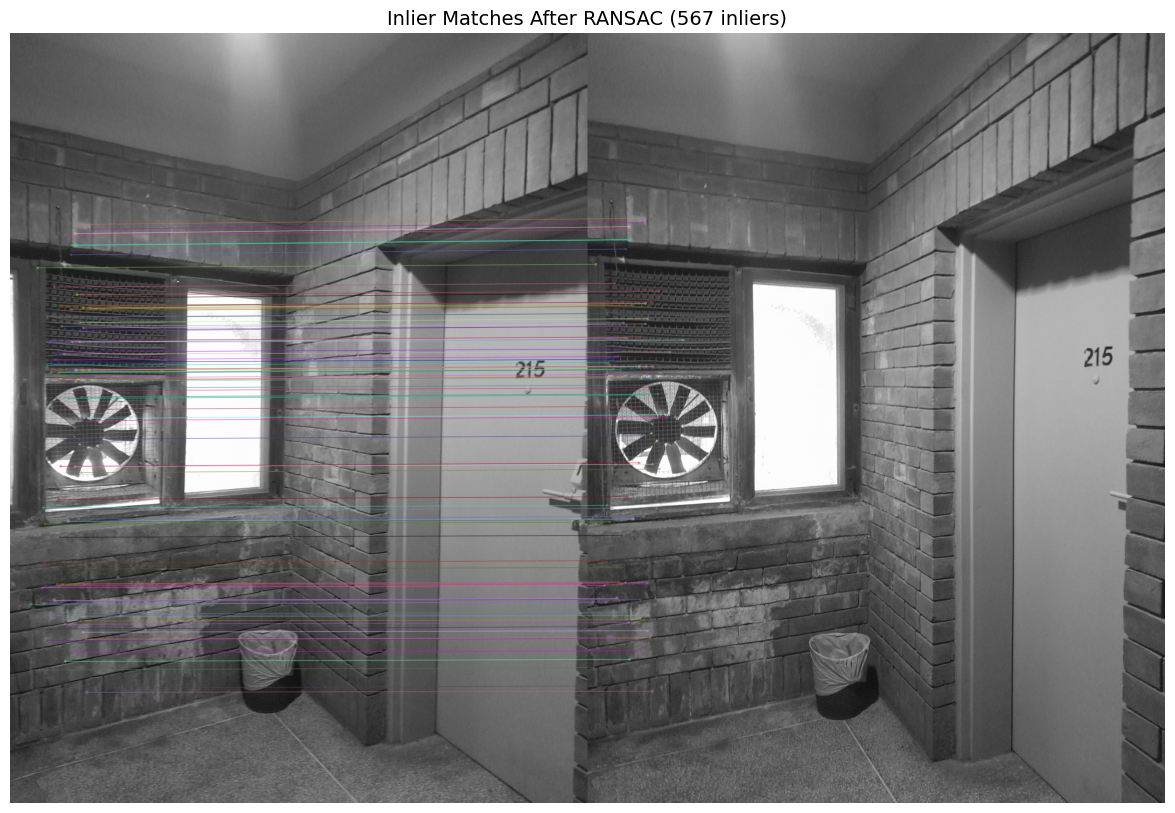

In [242]:

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

print("\nEssential Matrix Estimation")
print(f"Using {len(pts1)} matched points")



E, mask_e = cv2.findEssentialMat(
    pts1, pts2, K, 
    method=cv2.RANSAC, 
    prob=0.999, 
    threshold=BEST_RANSAC  
)


inliers = mask_e.ravel() == 1
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]
matches_inliers = [matches[i] for i in range(len(matches)) if inliers[i]]

print(E)
print(f"\nInliers after RANSAC: {np.sum(inliers)} / {len(pts1)}")
print(f"Inlier ratio: {np.sum(inliers)/len(pts1)*100:.2f}%")


img_inliers = cv2.drawMatches(
    img1_gray, kp1, img2_gray, kp2, matches_inliers[:100], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
plt.imshow(img_inliers, cmap='gray')
plt.title(f'Inlier Matches After RANSAC ({len(matches_inliers)} inliers)', fontsize=14)
plt.axis('off')
plt.show()

## 3. Camera Pose Recovery



In [243]:



num_inliers, R, t, mask_pose = cv2.recoverPose(E, pts1_inliers, pts2_inliers, K)

print(f"\nRotation Matrix R:")
print(R)
print(f"\nTranslation Vector t:")
print(t.ravel())
print(f"\nNumber of points in front of both cameras: {num_inliers}")


det_R = np.linalg.det(R)
print(f"\nDeterminant of R (should be ~1): {det_R:.6f}")
print(f"R is orthogonal: {np.allclose(R @ R.T, np.eye(3))}")


Rotation Matrix R:
[[ 0.99724622  0.00792001  0.07373765]
 [-0.00714403  0.99991636 -0.01078127]
 [-0.07381687  0.01022479  0.9972194 ]]

Translation Vector t:
[-0.9119721   0.00303311 -0.41024102]

Number of points in front of both cameras: 567

Determinant of R (should be ~1): 1.000000
R is orthogonal: True


## 4. 3D Point Triangulation

Triangulate 3D points from two camera views.

In [244]:




P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])


P2 = K @ np.hstack([R, t])

print("Projection Matrix P1 (Camera 1):")
print(P1)
print("\nProjection Matrix P2 (Camera 2):")
print(P2)


print(f"\nTriangulating {len(pts1_inliers)} points...")
points_4d_hom = cv2.triangulatePoints(P1, P2, pts1_inliers.T, pts2_inliers.T)


points_3d = points_4d_hom[:3] / points_4d_hom[3]
points_3d = points_3d.T  

print(f"Generated {len(points_3d)} 3D points")
print(f"\n3D points statistics:")
print(f"X range: [{points_3d[:, 0].min():.2f}, {points_3d[:, 0].max():.2f}]")
print(f"Y range: [{points_3d[:, 1].min():.2f}, {points_3d[:, 1].max():.2f}]")
print(f"Z range: [{points_3d[:, 2].min():.2f}, {points_3d[:, 2].max():.2f}]")

Projection Matrix P1 (Camera 1):
[[1.44e+03 0.00e+00 9.60e+02 0.00e+00]
 [0.00e+00 1.44e+03 1.28e+03 0.00e+00]
 [0.00e+00 0.00e+00 1.00e+00 0.00e+00]]

Projection Matrix P2 (Camera 2):
[[ 1.36517037e+03  2.12206141e+01  1.06351284e+03 -1.70707120e+03]
 [-1.04773007e+02  1.45296729e+03  1.26091580e+03 -5.20740821e+02]
 [-7.38168730e-02  1.02247929e-02  9.97219396e-01 -4.10241018e-01]]

Triangulating 567 points...
Generated 567 3D points

3D points statistics:
X range: [-22.48, 3.35]
Y range: [-6.91, 6.69]
Z range: [5.62, 41.53]


In [245]:


valid_mask = filter_points(points_3d, pts1_inliers, pts2_inliers, R, t, K, max_reproj_error=BEST_REPROJ)  
points_3d_filtered = points_3d[valid_mask]

print(f"Valid points after filtering: {len(points_3d_filtered)} / {len(points_3d)}")
print(f"Filtered ratio: {len(points_3d_filtered)/len(points_3d)*100:.2f}%")

print(f"Filtered 3D points statistics:")
print(f"X range: [{points_3d_filtered[:, 0].min():.2f}, {points_3d_filtered[:, 0].max():.2f}]")
print(f"Y range: [{points_3d_filtered[:, 1].min():.2f}, {points_3d_filtered[:, 1].max():.2f}]")
print(f"Z range: [{points_3d_filtered[:, 2].min():.2f}, {points_3d_filtered[:, 2].max():.2f}]")

Valid points after filtering: 567 / 567
Filtered ratio: 100.00%
Filtered 3D points statistics:
X range: [-22.48, 3.35]
Y range: [-6.91, 6.69]
Z range: [5.62, 41.53]


## 5. Extract Point Colors

Get RGB colors for each 3D point from the original image.

In [246]:

colors = []
for i, is_valid in enumerate(valid_mask):
    if is_valid:
        x, y = pts1_inliers[i].astype(int)
        
        y = np.clip(y, 0, img1_color.shape[0] - 1)
        x = np.clip(x, 0, img1_color.shape[1] - 1)
        color = img1_color[y, x]
        colors.append(color)

colors = np.array(colors)
print(f"\nExtracted colors for {len(colors)} points")


Extracted colors for 567 points


## 6. 2D Scatter Plots of 3D Point Cloud

Display 2D projections (XY, XZ, YZ) of the reconstructed point cloud.

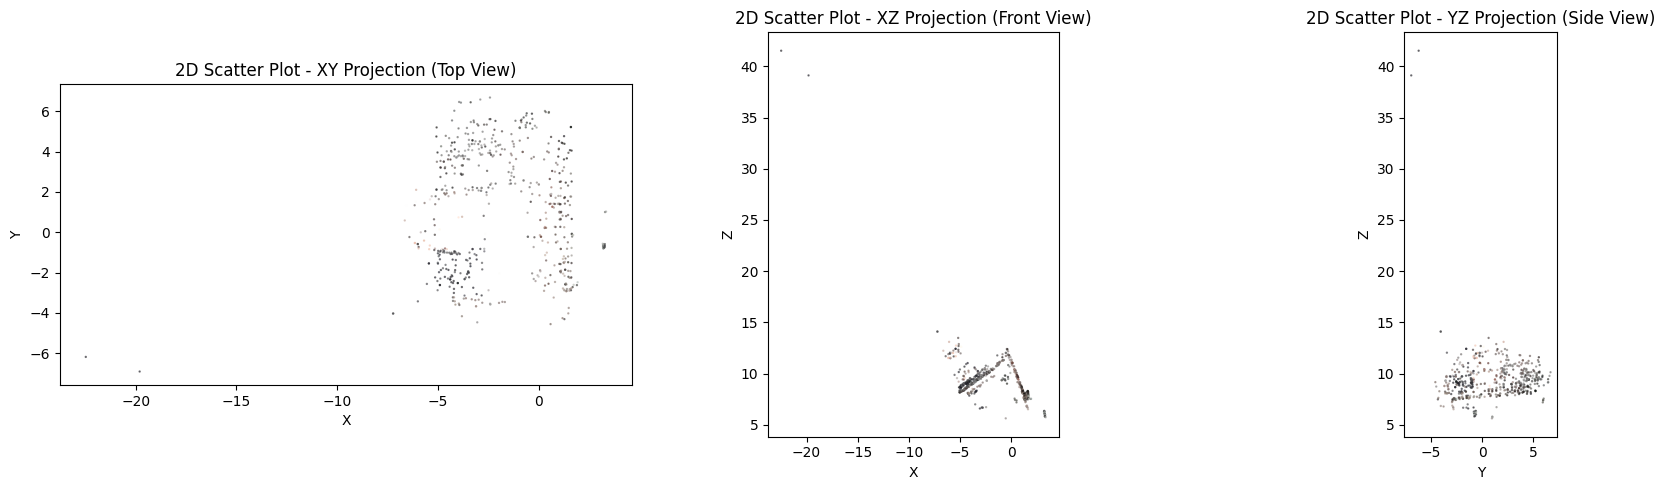

In [247]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(points_3d_filtered[:, 0], points_3d_filtered[:, 1], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('2D Scatter Plot - XY Projection (Top View)')
axes[0].set_aspect('equal')


axes[1].scatter(points_3d_filtered[:, 0], points_3d_filtered[:, 2], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
axes[1].set_title('2D Scatter Plot - XZ Projection (Front View)')
axes[1].set_aspect('equal')


axes[2].scatter(points_3d_filtered[:, 1], points_3d_filtered[:, 2], 
                c=colors/255.0, marker='.', s=2, alpha=0.6)
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
axes[2].set_title('2D Scatter Plot - YZ Projection (Side View)')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

## 7. 3D Point Cloud Visualization

Display the reconstructed point cloud with camera positions.

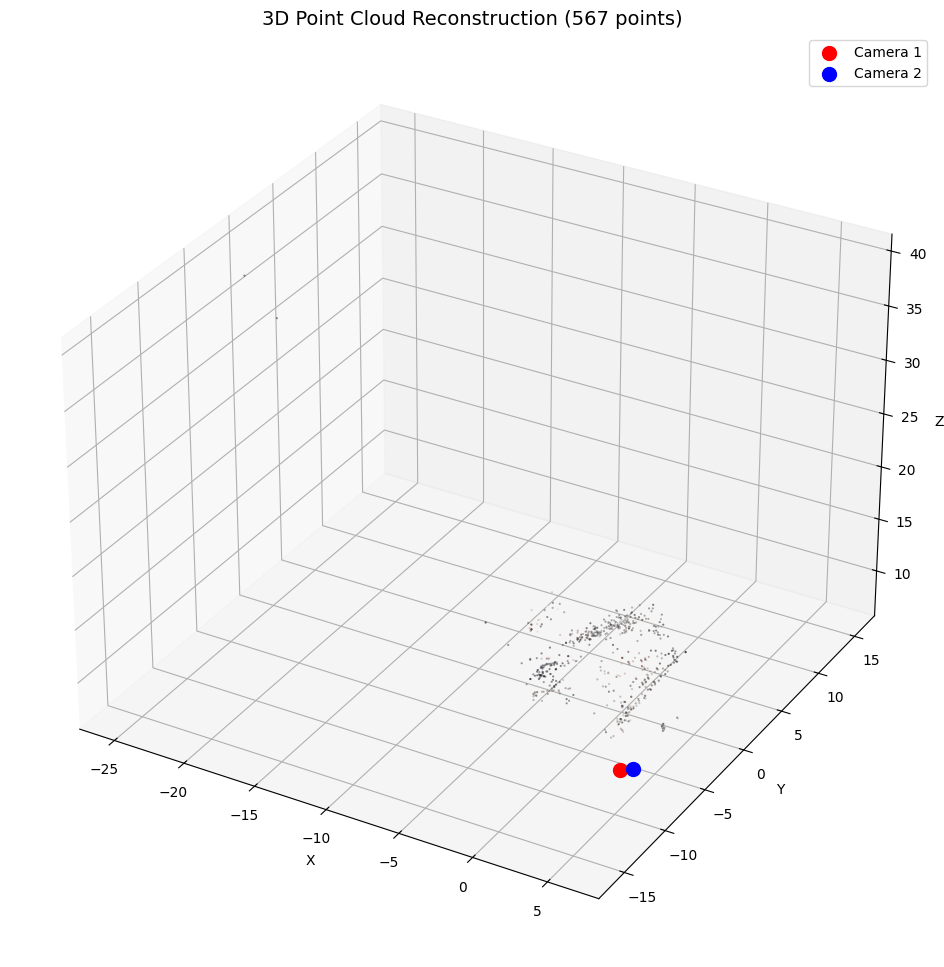

In [248]:

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(
    points_3d_filtered[:, 0], 
    points_3d_filtered[:, 1], 
    points_3d_filtered[:, 2],
    c=colors/255.0,  
    marker='.',
    s=1,
    alpha=0.6
)


ax.scatter([0], [0], [0], c='red', marker='o', s=100, label='Camera 1')
cam2_pos = -R.T @ t
ax.scatter([cam2_pos[0]], [cam2_pos[1]], [cam2_pos[2]], 
           c='blue', marker='o', s=100, label='Camera 2')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'3D Point Cloud Reconstruction ({len(points_3d_filtered)} points)', fontsize=14)
ax.legend()


max_range = np.array([
    points_3d_filtered[:, 0].max() - points_3d_filtered[:, 0].min(),
    points_3d_filtered[:, 1].max() - points_3d_filtered[:, 1].min(),
    points_3d_filtered[:, 2].max() - points_3d_filtered[:, 2].min()
]).max() / 2.0

mid_x = (points_3d_filtered[:, 0].max() + points_3d_filtered[:, 0].min()) * 0.5
mid_y = (points_3d_filtered[:, 1].max() + points_3d_filtered[:, 1].min()) * 0.5
mid_z = (points_3d_filtered[:, 2].max() + points_3d_filtered[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()

## 8. Save Point Cloud as PLY File

Export the final 3D point cloud to PLY format.

In [249]:
def save_ply(filename, points, colors):
  
    with open(filename, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(points)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")
        
        for i in range(len(points)):
            f.write(f"{points[i, 0]:.6f} {points[i, 1]:.6f} {points[i, 2]:.6f} ")
            f.write(f"{int(colors[i, 0])} {int(colors[i, 1])} {int(colors[i, 2])}\n")
    
    print(f"Saved {len(points)} points to {filename}")


save_ply('reconstruction.ply', points_3d_filtered, colors)
print(f"\nPoint cloud saved successfully!")

Saved 567 points to reconstruction.ply

Point cloud saved successfully!


## 9. Inline Point Cloud Visualization

Display the reconstructed point cloud from multiple angles directly in the notebook.

Loaded 567 points from reconstruction.ply


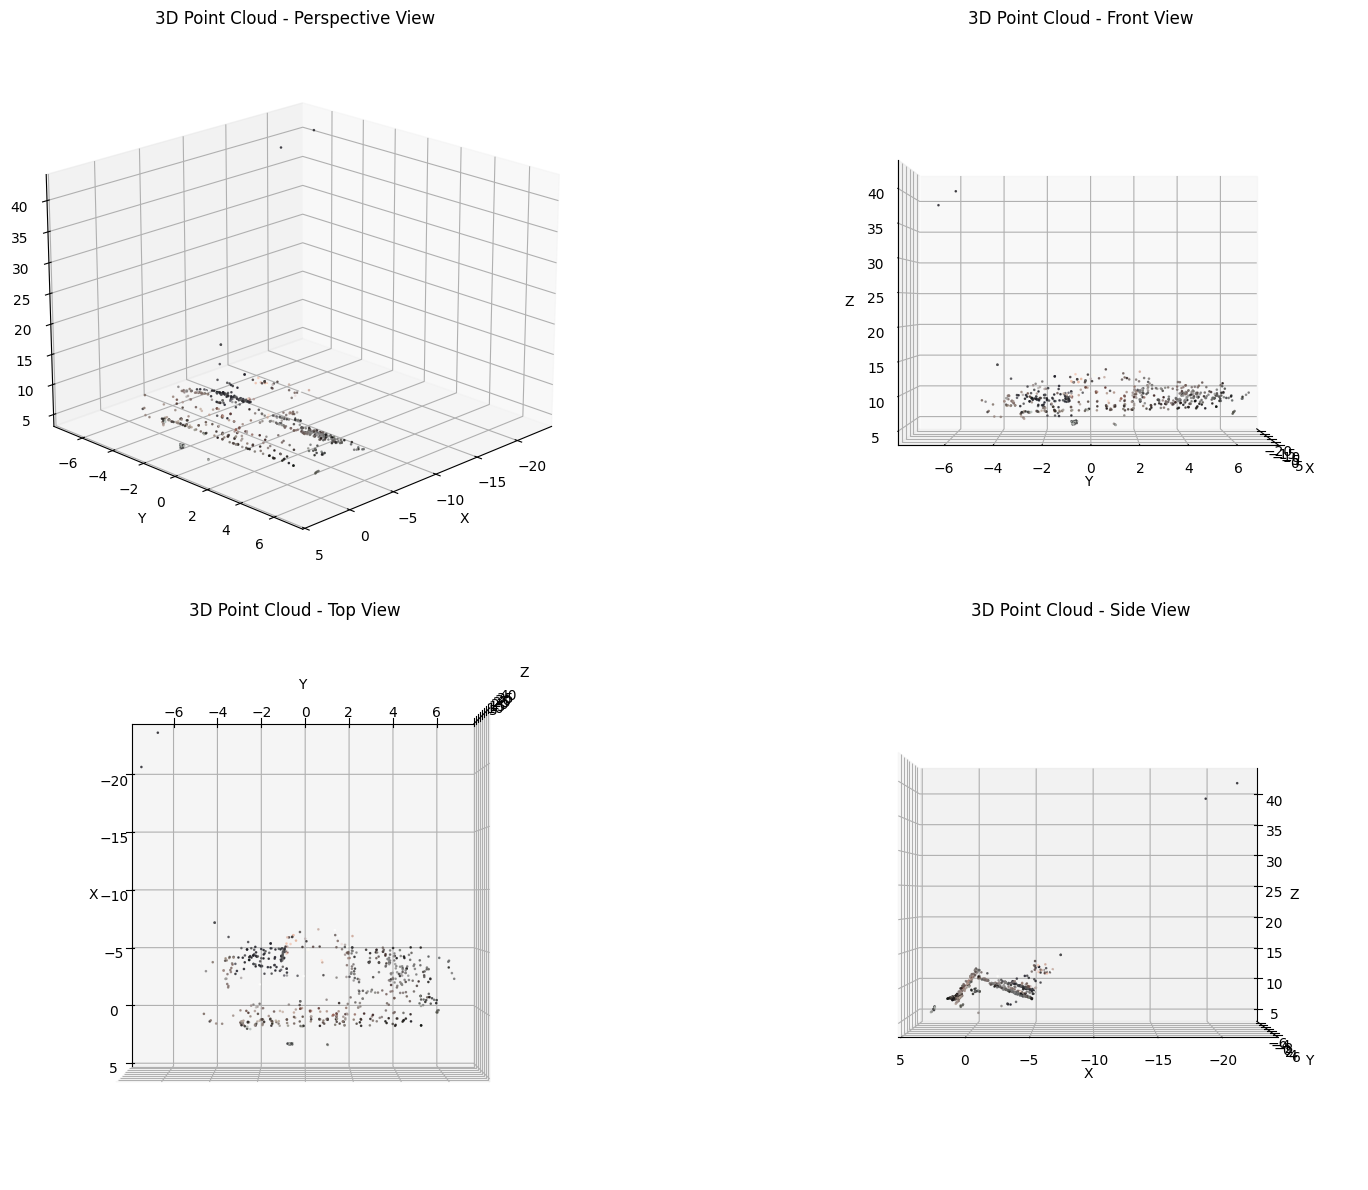


Point cloud visualization complete!
  Total points: 567
  X range: [-22.48, 3.35]
  Y range: [-6.91, 6.69]
  Z range: [5.62, 41.53]


In [250]:



def read_ply(filename):
   
    points = []
    colors = []
    
    with open(filename, 'r') as f:
        
        line = f.readline()
        while 'end_header' not in line:
            line = f.readline()
        
        
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                points.append([float(parts[0]), float(parts[1]), float(parts[2])])
                colors.append([int(parts[3]), int(parts[4]), int(parts[5])])
    
    return np.array(points), np.array(colors)


ply_points, ply_colors = read_ply('reconstruction.ply')
print(f"Loaded {len(ply_points)} points from reconstruction.ply")


fig = plt.figure(figsize=(18, 12))


ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Point Cloud - Perspective View')
ax1.view_init(elev=20, azim=45)


ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D Point Cloud - Front View')
ax2.view_init(elev=0, azim=0)


ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('3D Point Cloud - Top View')
ax3.view_init(elev=90, azim=0)


ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(ply_points[:, 0], ply_points[:, 1], ply_points[:, 2],
           c=ply_colors/255.0, marker='.', s=3, alpha=0.8)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('3D Point Cloud - Side View')
ax4.view_init(elev=0, azim=90)

plt.tight_layout()
plt.show()

print(f"\nPoint cloud visualization complete!")
print(f"  Total points: {len(ply_points)}")
print(f"  X range: [{ply_points[:, 0].min():.2f}, {ply_points[:, 0].max():.2f}]")
print(f"  Y range: [{ply_points[:, 1].min():.2f}, {ply_points[:, 1].max():.2f}]")
print(f"  Z range: [{ply_points[:, 2].min():.2f}, {ply_points[:, 2].max():.2f}]")

## 10. Interactive Open3D Visualization

Open the point cloud in an interactive 3D viewer window (requires running the cell).

In [251]:

print("Opening interactive 3D viewer...")
pcd = o3d.io.read_point_cloud("reconstruction.ply")
print(f"Points in reconstruction.ply: {len(pcd.points)}")
o3d.visualization.draw_geometries([pcd], window_name="Two-View Reconstruction")

Opening interactive 3D viewer...
Points in reconstruction.ply: 567



# Week 3: Incremental SfM

In [252]:
class IncrementalSfM:
    """
    Incremental Structure from Motion pipeline.
    """
    
    def __init__(self, K, images_color, keypoints_list, descriptors_list):
        """
        Initialize the SfM system.
        
        Args:
            K: 3x3 camera intrinsic matrix
            images_color: List of RGB images
            keypoints_list: List of keypoints for each image
            descriptors_list: List of descriptors for each image
        """
        self.K = K
        self.images_color = images_color
        self.keypoints_list = keypoints_list
        self.descriptors_list = descriptors_list
        
        # Reconstruction state
        self.poses = {}  # img_idx -> [R|t] (3x4 matrix)
        self.points_3d = np.array([]).reshape(0, 3)  # Nx3 array
        self.point_colors = np.array([]).reshape(0, 3)  # Nx3 array
        self.point_observations = {}  # point_idx -> [(img_idx, kp_idx), ...]
        self.registered_images = set()
        
        # Feature matcher
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50)
        self.flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    
    def match_features(self, desc1, desc2, ratio_thresh=0.75):
        """Match features using Lowe's ratio test."""
        matches = self.flann.knnMatch(desc1, desc2, k=2)
        
        good_matches = []
        for match_pair in matches:
            if len(match_pair) == 2:
                m, n = match_pair
                if m.distance < ratio_thresh * n.distance:
                    good_matches.append(m)
        
        return good_matches
    
    
    def initialize_from_two_views(self, img_idx1, img_idx2, ratio_thresh=0.75):
        """
        Initialize reconstruction from two views.
        
        Args:
            img_idx1, img_idx2: Indices of the two images
            ratio_thresh: Ratio test threshold for feature matching
            
        Returns:
            bool: Success status
        """
        print(f"\n{'='*70}")
        print(f"INITIALIZING FROM IMAGES {img_idx1} and {img_idx2}")
        print(f"{'='*70}")
        
        # Match features
        matches = self.match_features(
            self.descriptors_list[img_idx1],
            self.descriptors_list[img_idx2],
            ratio_thresh
        )
        
        if len(matches) < 100:
            print(f"Γ¥î Not enough matches: {len(matches)}")
            return False
        
        print(f"Found {len(matches)} feature matches")
        
        # Get matched points
        pts1 = np.float32([self.keypoints_list[img_idx1][m.queryIdx].pt for m in matches])
        pts2 = np.float32([self.keypoints_list[img_idx2][m.trainIdx].pt for m in matches])
        
        # Estimate Essential Matrix
        E, mask_e = cv2.findEssentialMat(pts1, pts2, self.K, method=cv2.RANSAC, 
                                          prob=0.999, threshold=1.0)
        
        if E is None:
            print("Γ¥î Essential matrix estimation failed")
            return False
        
        inliers = mask_e.ravel() == 1
        pts1_in = pts1[inliers]
        pts2_in = pts2[inliers]
        matches_in = [m for m, is_inlier in zip(matches, inliers) if is_inlier]
        
        print(f"Essential matrix inliers: {len(pts1_in)}/{len(pts1)}")
        
        # Recover pose
        _, R, t, mask_pose = cv2.recoverPose(E, pts1_in, pts2_in, self.K)
        
        # Set poses (first camera at origin)
        self.poses[img_idx1] = np.hstack([np.eye(3), np.zeros((3, 1))])
        self.poses[img_idx2] = np.hstack([R, t])
        
        print(f"Camera poses recovered")
        print(f"Translation: {t.ravel()}")
        print(f"Translation magnitude: {np.linalg.norm(t):.3f}")
        
        # Triangulate points
        P1 = self.K @ self.poses[img_idx1]
        P2 = self.K @ self.poses[img_idx2]
        
        points_4d = cv2.triangulatePoints(P1, P2, pts1_in.T, pts2_in.T)
        points_3d = (points_4d[:3] / points_4d[3]).T
        
        # Filter points by depth and reprojection error
        valid_mask = self._filter_points(
            points_3d, pts1_in, pts2_in, 
            self.poses[img_idx1], self.poses[img_idx2],
            max_reproj_error=8.0, max_depth=100.0
        )
        
        points_3d_valid = points_3d[valid_mask]
        pts1_valid = pts1_in[valid_mask]
        matches_valid = [m for m, is_valid in zip(matches_in, valid_mask) if is_valid]
        
        print(f"Valid 3D points after filtering: {len(points_3d_valid)}/{len(points_3d)}")
        
        if len(points_3d_valid) < 50:
            print(f"Γ¥î Not enough valid 3D points: {len(points_3d_valid)}")
            return False
        
        # Add points to reconstruction
        self.points_3d = points_3d_valid
        
        # Extract colors
        colors = []
        for pt in pts1_valid:
            x, y = int(pt[0]), int(pt[1])
            y = np.clip(y, 0, self.images_color[img_idx1].shape[0] - 1)
            x = np.clip(x, 0, self.images_color[img_idx1].shape[1] - 1)
            color = self.images_color[img_idx1][y, x]
            colors.append(color)
        
        self.point_colors = np.array(colors)
        
        # Track observations
        self.point_observations = {}
        for i, match in enumerate(matches_valid):
            kp_idx1 = match.queryIdx
            kp_idx2 = match.trainIdx
            self.point_observations[i] = [
                (img_idx1, kp_idx1),
                (img_idx2, kp_idx2)
            ]
        
        self.registered_images.add(img_idx1)
        self.registered_images.add(img_idx2)
        
        print(f"Γ£ô Initialization successful!")
        print(f"  Registered: 2 cameras")
        print(f"  3D points: {len(self.points_3d):,}")
        print(f"{'='*70}\n")
        
        return True
    
    
    def _filter_points(self, points_3d, pts1, pts2, pose1, pose2, 
                       max_reproj_error=8.0, max_depth=100.0):
        """
        Filter 3D points based on depth and reprojection error.
        
        Returns:
            bool array indicating valid points
        """
        R1, t1 = pose1[:, :3], pose1[:, 3:]
        R2, t2 = pose2[:, :3], pose2[:, 3:]
        
        # Check depth in both cameras
        points_cam1 = (R1 @ points_3d.T + t1).T
        points_cam2 = (R2 @ points_3d.T + t2).T
        
        depth_valid = (points_cam1[:, 2] > 0) & (points_cam1[:, 2] < max_depth) & \
                      (points_cam2[:, 2] > 0) & (points_cam2[:, 2] < max_depth)
        
        # Check reprojection error
        points_2d_proj1 = (self.K @ points_cam1.T).T
        points_2d_proj1 = points_2d_proj1[:, :2] / points_2d_proj1[:, 2:3]
        reproj_error1 = np.linalg.norm(points_2d_proj1 - pts1, axis=1)
        
        points_2d_proj2 = (self.K @ points_cam2.T).T
        points_2d_proj2 = points_2d_proj2[:, :2] / points_2d_proj2[:, 2:3]
        reproj_error2 = np.linalg.norm(points_2d_proj2 - pts2, axis=1)
        
        reproj_valid = (reproj_error1 < max_reproj_error) & (reproj_error2 < max_reproj_error)
        
        return depth_valid & reproj_valid
    
    
    def add_view_pnp(self, img_idx, ratio_thresh=0.75, min_correspondences=15, 
                     reproj_error_thresh=8.0):
        """
        Add a new view using PnP (Perspective-n-Point).
        
        Args:
            img_idx: Index of the image to add
            ratio_thresh: Feature matching ratio threshold
            min_correspondences: Minimum 2D-3D correspondences needed
            reproj_error_thresh: RANSAC reprojection error threshold
            
        Returns:
            bool: Success status
        """
        print(f"\n{'='*70}")
        print(f"ADDING IMAGE {img_idx} USING PnP")
        print(f"{'='*70}")
        
        # Collect 2D-3D correspondences
        points_2d = []
        points_3d_corr = []
        point_3d_indices = []
        
        # Match with all registered images
        for reg_img_idx in sorted(self.registered_images):
            matches = self.match_features(
                self.descriptors_list[img_idx],
                self.descriptors_list[reg_img_idx],
                ratio_thresh
            )
            
            # Find which matches correspond to 3D points
            for match in matches:
                kp_idx_new = match.queryIdx
                kp_idx_reg = match.trainIdx
                
                # Search for 3D points observed from registered image
                for pt_idx, observations in self.point_observations.items():
                    for obs_img_idx, obs_kp_idx in observations:
                        if obs_img_idx == reg_img_idx and obs_kp_idx == kp_idx_reg:
                            # Found a 2D-3D correspondence!
                            pt_2d = self.keypoints_list[img_idx][kp_idx_new].pt
                            
                            # Check if not already added
                            is_duplicate = False
                            for existing_pt, existing_3d_idx in zip(points_2d, point_3d_indices):
                                if np.allclose(existing_pt, pt_2d, atol=0.5) and existing_3d_idx == pt_idx:
                                    is_duplicate = True
                                    break
                            
                            if not is_duplicate:
                                points_2d.append(pt_2d)
                                points_3d_corr.append(self.points_3d[pt_idx])
                                point_3d_indices.append(pt_idx)
                            break
        
        points_2d = np.array(points_2d, dtype=np.float32)
        points_3d_corr = np.array(points_3d_corr, dtype=np.float32)
        
        print(f"Found {len(points_2d)} 2D-3D correspondences")
        
        if len(points_2d) < min_correspondences:
            print(f"Γ¥î Not enough correspondences (need {min_correspondences})")
            return False
        
        # Solve PnP with RANSAC
        success, rvec, tvec, inliers = cv2.solvePnPRansac(
            points_3d_corr,
            points_2d,
            self.K,
            None,  # No distortion
            flags=cv2.SOLVEPNP_ITERATIVE,
            reprojectionError=reproj_error_thresh,
            confidence=0.99,
            iterationsCount=1000
        )
        
        if not success or inliers is None or len(inliers) < min_correspondences:
            print(f"Γ¥î PnP failed (inliers: {len(inliers) if inliers is not None else 0})")
            return False
        
        # Convert rotation vector to matrix
        R_new, _ = cv2.Rodrigues(rvec)
        t_new = tvec
        pose_new = np.hstack([R_new, t_new])
        
        # Add pose
        self.poses[img_idx] = pose_new
        self.registered_images.add(img_idx)
        
        inlier_ratio = len(inliers) / len(points_2d) * 100
        
        print(f"Γ£ô PnP successful!")
        print(f"  Inliers: {len(inliers)} / {len(points_2d)} ({inlier_ratio:.1f}%)")
        print(f"  Translation: {t_new.ravel()}")
        
        return True
    
    
    def triangulate_new_points(self, img_idx, ratio_thresh=0.75, 
                                max_reproj_error=10.0, max_depth=100.0):
        """
        Triangulate new 3D points between newly added camera and registered cameras.
        
        Args:
            img_idx: Index of newly added image
            ratio_thresh: Feature matching ratio threshold
            max_reproj_error: Maximum reprojection error for valid points
            max_depth: Maximum depth for valid points
            
        Returns:
            int: Number of new points added
        """
        print(f"\nTriangulating new points with Image {img_idx}...")
        
        if img_idx not in self.poses:
            print(f"  Γ¥î Image {img_idx} not in poses")
            return 0
        
        new_points = []
        new_colors = []
        new_observations = []
        
        P_new = self.K @ self.poses[img_idx]
        
        # Try triangulating with all registered images (except itself)
        for reg_img_idx in sorted(self.registered_images):
            if reg_img_idx == img_idx or reg_img_idx not in self.poses:
                continue
            
            # Match features
            matches = self.match_features(
                self.descriptors_list[img_idx],
                self.descriptors_list[reg_img_idx],
                ratio_thresh
            )
            
            if len(matches) < 8:
                continue
            
            # Filter out matches that already have 3D points
            valid_matches = []
            for match in matches:
                kp_idx_new = match.queryIdx
                kp_idx_reg = match.trainIdx
                
                # Check if either keypoint is already part of a 3D point
                already_has_point = False
                for observations in self.point_observations.values():
                    for obs_img_idx, obs_kp_idx in observations:
                        if (obs_img_idx == img_idx and obs_kp_idx == kp_idx_new) or \
                           (obs_img_idx == reg_img_idx and obs_kp_idx == kp_idx_reg):
                            already_has_point = True
                            break
                    if already_has_point:
                        break
                
                if not already_has_point:
                    valid_matches.append(match)
            
            if len(valid_matches) < 8:
                continue
            
            # Get points
            pts_new = np.float32([self.keypoints_list[img_idx][m.queryIdx].pt for m in valid_matches])
            pts_reg = np.float32([self.keypoints_list[reg_img_idx][m.trainIdx].pt for m in valid_matches])
            
            # Triangulate
            P_reg = self.K @ self.poses[reg_img_idx]
            points_4d = cv2.triangulatePoints(P_reg, P_new, pts_reg.T, pts_new.T)
            points_3d_new = (points_4d[:3] / points_4d[3]).T
            
            # Filter points
            valid_mask = self._filter_points(
                points_3d_new, pts_reg, pts_new,
                self.poses[reg_img_idx], self.poses[img_idx],
                max_reproj_error, max_depth
            )
            
            # Add valid points
            for i, is_valid in enumerate(valid_mask):
                if is_valid:
                    new_points.append(points_3d_new[i])
                    
                    # Get color from new image
                    pt = pts_new[i]
                    y, x = int(pt[1]), int(pt[0])
                    y = np.clip(y, 0, self.images_color[img_idx].shape[0] - 1)
                    x = np.clip(x, 0, self.images_color[img_idx].shape[1] - 1)
                    color = self.images_color[img_idx][y, x]
                    new_colors.append(color)
                    
                    # Track observations
                    kp_idx_new = valid_matches[i].queryIdx
                    kp_idx_reg = valid_matches[i].trainIdx
                    new_observations.append([
                        (img_idx, kp_idx_new),
                        (reg_img_idx, kp_idx_reg)
                    ])
        
        if len(new_points) == 0:
            print(f"  No new points triangulated")
            return 0
        
        # Add to reconstruction
        num_existing = len(self.points_3d)
        new_points = np.array(new_points)
        new_colors = np.array(new_colors)
        
        self.points_3d = np.vstack([self.points_3d, new_points]) if len(self.points_3d) > 0 else new_points
        self.point_colors = np.vstack([self.point_colors, new_colors]) if len(self.point_colors) > 0 else new_colors
        
        # Add observations
        for i, obs in enumerate(new_observations):
            pt_idx = num_existing + i
            self.point_observations[pt_idx] = obs
        
        print(f"  Γ£ô Added {len(new_points)} new 3D points")
        print(f"  Total points: {len(self.points_3d):,}")
        
        return len(new_points)
    
    
    def bundle_adjustment(self, max_iterations=50, verbose=True):
        """
        Perform bundle adjustment to refine camera poses and 3D points.
        
        Args:
            max_iterations: Maximum number of optimization iterations
            verbose: Print optimization progress
            
        Returns:
            dict: Statistics about the optimization
        """
        print(f"\n{'='*70}")
        print("BUNDLE ADJUSTMENT")
        print(f"{'='*70}")
        print(f"Cameras: {len(self.poses)}")
        print(f"3D points: {len(self.points_3d)}")
        
        # Build observation list
        observations = []
        camera_indices = []
        point_indices = []
        
        # Create camera index mapping (sorted image indices)
        camera_idx_map = {img_idx: i for i, img_idx in enumerate(sorted(self.poses.keys()))}
        
        for pt_idx, obs_list in self.point_observations.items():
            if pt_idx >= len(self.points_3d):
                continue
            
            for img_idx, kp_idx in obs_list:
                if img_idx not in self.poses:
                    continue
                
                kp = self.keypoints_list[img_idx][kp_idx]
                observations.append([kp.pt[0], kp.pt[1]])
                camera_indices.append(camera_idx_map[img_idx])
                point_indices.append(pt_idx)
        
        observations = np.array(observations)
        camera_indices = np.array(camera_indices)
        point_indices = np.array(point_indices)
        
        num_cameras = len(self.poses)
        num_points = len(self.points_3d)
        num_observations = len(observations)
        
        print(f"Observations: {num_observations:,}")
        print(f"Avg observations/camera: {num_observations/num_cameras:.1f}")
        print(f"Avg observations/point: {num_observations/num_points:.1f}")
        
        if num_observations < 100:
            print("ΓÜá∩╕Å  Too few observations for bundle adjustment")
            return {'success': False, 'message': 'Too few observations'}
        
        # Convert poses to parameter vector
        camera_params = []
        for img_idx in sorted(self.poses.keys()):
            pose = self.poses[img_idx]
            R = pose[:, :3]
            t = pose[:, 3:]
            rvec, _ = cv2.Rodrigues(R)
            camera_params.append(np.concatenate([rvec.ravel(), t.ravel()]))
        
        camera_params = np.concatenate(camera_params)
        point_params = self.points_3d.ravel()
        x0 = np.concatenate([camera_params, point_params])
        
        print(f"\nOptimization parameters:")
        print(f"  Camera params: {len(camera_params)} ({num_cameras} cameras ├ù 6)")
        print(f"  Point params: {len(point_params)} ({num_points} points ├ù 3)")
        print(f"  Total params: {len(x0):,}")
        print(f"\nStarting optimization...\n")
        
        # Define residual function
        def residuals(params):
            cam_params = params[:num_cameras*6].reshape((num_cameras, 6))
            pt_params = params[num_cameras*6:].reshape((num_points, 3))
            
            residuals = []
            for i in range(len(observations)):
                c_idx = camera_indices[i]
                p_idx = point_indices[i]
                observed = observations[i]
                
                # Get camera params
                rvec = cam_params[c_idx, :3]
                tvec = cam_params[c_idx, 3:]
                
                # Get 3D point
                point_3d = pt_params[p_idx]
                
                # Project to 2D
                R, _ = cv2.Rodrigues(rvec)
                pt_cam = R @ point_3d + tvec
                
                # Handle points behind camera
                if pt_cam[2] <= 0:
                    residuals.extend([100.0, 100.0])
                    continue
                
                pt_2d = self.K @ pt_cam
                pt_2d = pt_2d[:2] / pt_2d[2]
                
                # Compute error
                error = observed - pt_2d
                residuals.extend([error[0], error[1]])
            
            return np.array(residuals)
        
        # Compute initial cost
        initial_residuals = residuals(x0)
        initial_cost = np.sum(initial_residuals**2)
        
        # Optimize
        result = least_squares(
            residuals,
            x0,
            method='lm',
            verbose=2 if verbose else 0,
            max_nfev=max_iterations,
            ftol=1e-4,
            xtol=1e-4
        )
        
        print(f"\n{'='*70}")
        print("OPTIMIZATION COMPLETE")
        print(f"{'='*70}")
        print(f"Success: {result.success}")
        print(f"Message: {result.message}")
        print(f"Iterations: {result.nfev}")
        print(f"Initial cost: {initial_cost:.2f}")
        print(f"Final cost: {result.cost:.2f}")
        
        if initial_cost > 0:
            improvement = (1 - result.cost / initial_cost) * 100
            print(f"Improvement: {improvement:.1f}%")
        
        # Extract optimized parameters
        opt_params = result.x
        cam_params_opt = opt_params[:num_cameras*6].reshape((num_cameras, 6))
        pt_params_opt = opt_params[num_cameras*6:].reshape((num_points, 3))
        
        # Update poses
        for i, img_idx in enumerate(sorted(self.poses.keys())):
            rvec = cam_params_opt[i, :3]
            tvec = cam_params_opt[i, 3:]
            R, _ = cv2.Rodrigues(rvec)
            self.poses[img_idx] = np.hstack([R, tvec.reshape(3, 1)])
        
        # Update points
        self.points_3d = pt_params_opt
        
        print(f"{'='*70}\n")
        
        return {
            'success': result.success,
            'message': result.message,
            'iterations': result.nfev,
            'initial_cost': initial_cost,
            'final_cost': result.cost,
            'improvement': improvement if initial_cost > 0 else 0
        }
    
    
    def get_reconstruction_stats(self):
        """Get statistics about the current reconstruction."""
        stats = {
            'num_cameras': len(self.registered_images),
            'num_points': len(self.points_3d),
            'num_observations': sum(len(obs) for obs in self.point_observations.values()),
            'registered_images': sorted(list(self.registered_images))
        }
        
        if len(self.point_observations) > 0:
            avg_observations = stats['num_observations'] / len(self.point_observations)
            stats['avg_observations_per_point'] = avg_observations
        
        return stats
    
    
    def save_point_cloud(self, filename):
        """Save point cloud to PLY file."""
        with open(filename, 'w') as f:
            f.write("ply\n")
            f.write("format ascii 1.0\n")
            f.write(f"element vertex {len(self.points_3d)}\n")
            f.write("property float x\n")
            f.write("property float y\n")
            f.write("property float z\n")
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")
            f.write("end_header\n")
            
            for i in range(len(self.points_3d)):
                pt = self.points_3d[i]
                color = self.point_colors[i].astype(int)
                f.write(f"{pt[0]} {pt[1]} {pt[2]} {color[0]} {color[1]} {color[2]}\n")
        
        print(f"Γ£ô Saved point cloud to {filename}")


In [253]:
def run_incremental_sfm(K, images_color, keypoints_list, descriptors_list, 
                         init_pair, max_images=None, run_bundle_adjustment=False):
    """
    Run the complete incremental SfM pipeline.
    
    Args:
        K: Camera intrinsic matrix
        images_color: List of RGB images
        keypoints_list: List of keypoints for each image
        descriptors_list: List of descriptors for each image
        init_pair: Tuple of (img_idx1, img_idx2) for initialization
        max_images: Maximum number of images to process (None = all)
        run_bundle_adjustment: Whether to run bundle adjustment at the end
        
    Returns:
        IncrementalSfM: The SfM object with final reconstruction
    """
    sfm = IncrementalSfM(K, images_color, keypoints_list, descriptors_list)
    
    # Initialize from two views
    img_idx1, img_idx2 = init_pair
    success = sfm.initialize_from_two_views(img_idx1, img_idx2)
    
    if not success:
        print("Γ¥î Initialization failed!")
        return sfm
    
    # Determine order of images to add
    num_images = len(images_color) if max_images is None else min(max_images, len(images_color))
    
    # Add neighbors first (images near the initial pair)
    images_to_add = []
    for offset in [1, -1, 2, -2, 3, -3, 4, -4, 5, -5]:
        for init_img in [img_idx1, img_idx2]:
            neighbor = init_img + offset
            if 0 <= neighbor < num_images and neighbor not in sfm.registered_images:
                if neighbor not in images_to_add:
                    images_to_add.append(neighbor)
    
    # Add remaining images
    remaining = [i for i in range(num_images) 
                 if i not in sfm.registered_images and i not in images_to_add]
    images_to_add.extend(remaining)
    
    print(f"\n{'#'*70}")
    print(f"INCREMENTAL SfM - ADDING {len(images_to_add)} IMAGES")
    print(f"{'#'*70}")
    print(f"Initial pair: [{img_idx1}, {img_idx2}]")
    print(f"Order: {images_to_add[:15]}{'...' if len(images_to_add) > 15 else ''}")
    print(f"{'#'*70}\n")
    
    failed_images = []
    
    # Main loop - add views one by one
    for img_idx in images_to_add:
        # Try to add view with PnP
        success = sfm.add_view_pnp(img_idx)
        
        if not success:
            print(f"ΓÜá∩╕Å  Failed to add image {img_idx}\n")
            failed_images.append(img_idx)
            continue
        
        # Triangulate new points
        num_new_points = sfm.triangulate_new_points(img_idx)
        
        stats = sfm.get_reconstruction_stats()
        print(f"\n{'='*70}")
        print(f"Γ£ô Successfully added image {img_idx}")
        print(f"  Registered: {stats['num_cameras']}/{num_images} cameras")
        print(f"  3D points: {stats['num_points']:,}")
        print(f"  New points: +{num_new_points}")
        print(f"{'='*70}\n")
    
    # Retry failed images
    if failed_images:
        print(f"\n{'#'*70}")
        print(f"RETRYING {len(failed_images)} FAILED IMAGES")
        print(f"{'#'*70}\n")
        
        for img_idx in failed_images:
            success = sfm.add_view_pnp(img_idx, min_correspondences=10)
            
            if success:
                sfm.triangulate_new_points(img_idx)
                print(f"Γ£ô Successfully added image {img_idx} on retry!\n")
    
    # Final statistics
    final_stats = sfm.get_reconstruction_stats()
    print(f"\n{'#'*70}")
    print(f"INCREMENTAL SfM COMPLETE")
    print(f"{'#'*70}")
    print(f"Registered cameras: {final_stats['num_cameras']}/{num_images}")
    print(f"3D points: {final_stats['num_points']:,}")
    print(f"Observations: {final_stats['num_observations']:,}")
    if 'avg_observations_per_point' in final_stats:
        print(f"Avg observations/point: {final_stats['avg_observations_per_point']:.1f}")
    print(f"Registered images: {final_stats['registered_images']}")
    failed = [i for i in range(num_images) if i not in sfm.registered_images]
    if failed:
        print(f"Failed images: {failed}")
    print(f"{'#'*70}\n")
    
    # Bundle adjustment
    if run_bundle_adjustment and final_stats['num_cameras'] >= 3:
        print("Running bundle adjustment for refinement...")
        ba_stats = sfm.bundle_adjustment(max_iterations=50)
    
    return sfm



In [ ]:
# Choose two images for initialization
init_pair = (0, 1)     # use image 0 and 1 to start reconstruction

# Run the pipeline
sfm = run_incremental_sfm(
    K=K,
    images_color=images_color,
    keypoints_list=keypoints_list,
    descriptors_list=descriptors_list,
    init_pair=init_pair,
    max_images=None,              # or set limit like max_images=50
    run_bundle_adjustment=False    # turn BA on/off
)



INITIALIZING FROM IMAGES 0 and 1
Found 773 feature matches
Essential matrix inliers: 401/773
Camera poses recovered
Translation: [-0.91923498 -0.00502116 -0.39367732]
Translation magnitude: 1.000
Valid 3D points after filtering: 401/401
Γ£ô Initialization successful!
  Registered: 2 cameras
  3D points: 401


######################################################################
INCREMENTAL SfM - ADDING 30 IMAGES
######################################################################
Initial pair: [0, 1]
Order: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]...
######################################################################


ADDING IMAGE 2 USING PnP
Found 208 2D-3D correspondences
Γ£ô PnP successful!
  Inliers: 163 / 208 (78.4%)
  Translation: [-1.84546483 -0.12267383 -0.62395971]

Triangulating new points with Image 2...
  Γ£ô Added 1178 new 3D points
  Total points: 1,579

Γ£ô Successfully added image 2
  Registered: 3/32 cameras
  3D points: 1,579
  New points: +1178




In [ ]:
stats = sfm.get_reconstruction_stats()

print("\n" + "="*70)
print("PHASE 2 - RECONSTRUCTION RESULTS")
print("="*70)
print(f"\nCameras:")
print(f"   ΓÇó Registered: {stats['num_cameras']}/{len(images_color)}")
print(f"   ΓÇó Success rate: {stats['num_cameras']/len(images_color)*100:.1f}%")
print(f"   ΓÇó Image IDs: {stats['registered_images']}")

print(f"\n3D Points:")
print(f"   ΓÇó Total points: {stats['num_points']:,}")
print(f"   ΓÇó Observations: {stats['num_observations']:,}")
if 'avg_observations_per_point' in stats:
    print(f"   ΓÇó Avg views per point: {stats['avg_observations_per_point']:.2f}")

if len(sfm.points_3d) > 0:
    bbox = sfm.points_3d.max(axis=0) - sfm.points_3d.min(axis=0)
    print("Scene Size:")
    print(f"   ΓÇó X: {bbox[0]:.2f}")
    print(f"   ΓÇó Y: {bbox[1]:.2f}")
    print(f"   ΓÇó Z: {bbox[2]:.2f}")

print("="*70 + "\n")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Get points and colors
points = sfm.points_3d.copy()
colors = sfm.point_colors.copy() / 255.0  # Normalize to [0, 1]

# Subsample if too many (for performance)
if len(points) > 30000:
    idx = np.random.choice(len(points), 30000, replace=False)
    points = points[idx]
    colors = colors[idx]

# Plot point cloud
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=colors, s=1, alpha=0.5, marker='.')

# Plot camera positions
cam_positions = []
for img_idx in sorted(sfm.poses.keys()):
    pose = sfm.poses[img_idx]
    R, t = pose[:, :3], pose[:, 3]
    C = -R.T @ t  # Camera center
    cam_positions.append(C)

cam_positions = np.array(cam_positions)

# Plot cameras as red spheres
ax.scatter(cam_positions[:, 0], cam_positions[:, 1], cam_positions[:, 2],
           c='red', marker='o', s=200, 
           edgecolors='black', linewidths=2,
           label=f'{len(cam_positions)} Cameras')

# Connect cameras with dashed line
ax.plot(cam_positions[:, 0], cam_positions[:, 1], cam_positions[:, 2],
        'r--', alpha=0.4, linewidth=1.5)

# Labels
ax.set_xlabel('X', fontsize=12, fontweight='bold')
ax.set_ylabel('Y', fontsize=12, fontweight='bold')
ax.set_zlabel('Z', fontsize=12, fontweight='bold')
ax.set_title(f'Week 3 - 3D Reconstruction\n{len(sfm.points_3d):,} points, {len(sfm.poses)} cameras',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Equal aspect ratio
max_range = (points.max(axis=0) - points.min(axis=0)).max() / 2.0
mid = points.mean(axis=0)
ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

plt.tight_layout()
plt.show()

print("Γ£ô 3D visualization complete!")


In [ ]:

import matplotlib.pyplot as plt

points = sfm.points_3d
colors = sfm.point_colors / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XY (Top view)
axes[0].scatter(points[:, 0], points[:, 1], c=colors, s=1, alpha=0.5)
axes[0].set_xlabel('X', fontweight='bold')
axes[0].set_ylabel('Y', fontweight='bold')
axes[0].set_title('Top View (XY)', fontweight='bold')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

# XZ (Front view)
axes[1].scatter(points[:, 0], points[:, 2], c=colors, s=1, alpha=0.5)
axes[1].set_xlabel('X', fontweight='bold')
axes[1].set_ylabel('Z', fontweight='bold')
axes[1].set_title('Front View (XZ)', fontweight='bold')
axes[1].axis('equal')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

# YZ (Side view)
axes[2].scatter(points[:, 1], points[:, 2], c=colors, s=1, alpha=0.5)
axes[2].set_xlabel('Y', fontweight='bold')
axes[2].set_ylabel('Z', fontweight='bold')
axes[2].set_title('Side View (YZ)', fontweight='bold')
axes[2].axis('equal')
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'2D Projections - {len(points):,} points', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Γ£ô 2D projections complete!")

In [ ]:

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Subsample for performance
points = sfm.points_3d.copy()
colors = sfm.point_colors.copy() / 255.0

if len(points) > 20000:
    idx = np.random.choice(len(points), 20000, replace=False)
    points = points[idx]
    colors = colors[idx]

# Get camera positions
cam_pos = []
for pose in sfm.poses.values():
    R, t = pose[:, :3], pose[:, 3]
    cam_pos.append(-R.T @ t)
cam_pos = np.array(cam_pos)

# Create 4 views
fig = plt.figure(figsize=(16, 12))

views = [
    (30, 45, 'View 1 (30┬░, 45┬░)'),
    (30, 135, 'View 2 (30┬░, 135┬░)'),
    (30, 225, 'View 3 (30┬░, 225┬░)'),
    (30, 315, 'View 4 (30┬░, 315┬░)')
]

for i, (elev, azim, title) in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    # Points
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
               c=colors, s=1, alpha=0.5)
    
    # Cameras
    ax.scatter(cam_pos[:, 0], cam_pos[:, 1], cam_pos[:, 2],
               c='red', marker='o', s=100, edgecolors='black', linewidths=1.5)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Reconstruction from Multiple Angles - {len(sfm.points_3d):,} points',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Γ£ô Multiple angles visualization complete!")


In [ ]:
# Final export: full-room point cloud for Three.js

if 'sfm' not in globals():
    print("sfm is not defined. Run the Week 3 incremental SfM pipeline cell (run_incremental_sfm(...)) first.")
elif not hasattr(sfm, 'points_3d') or sfm.points_3d is None or len(sfm.points_3d) == 0:
    print("sfm has no points. Check earlier cells for errors and ensure the pipeline completed.")
else:
    output_name = 'final_room.ply'
    sfm.save_point_cloud(output_name)
    print(f"Saved final room cloud to {output_name}")

    # Quick sanity visualization (perspective + top)
    import matplotlib.pyplot as plt
    pts = sfm.points_3d
    cols = sfm.point_colors / 255.0 if hasattr(sfm, 'point_colors') and len(sfm.point_colors) == len(pts) else None
    fig = plt.figure(figsize=(12,5))
    ax1 = fig.add_subplot(1,2,1, projection='3d')
    ax1.scatter(pts[:,0], pts[:,1], pts[:,2], c=cols, s=1, alpha=0.6)
    ax1.set_title('Final room cloud - perspective'); ax1.view_init(20, 40)
    ax2 = fig.add_subplot(1,2,2, projection='3d')
    ax2.scatter(pts[:,0], pts[:,1], pts[:,2], c=cols, s=1, alpha=0.6)
    ax2.set_title('Final room cloud - top'); ax2.view_init(90, 0)
    for ax in (ax1, ax2):
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.tight_layout(); plt.show()

In [ ]:
# Build and save small parallax point clouds (3-4 images each) for manual stitching
import os
os.makedirs('partial_clouds', exist_ok=True)

# Define your high-parallax image groups (indices refer to the full dataset order)
parallax_groups = [
    [0, 1, 2, 3],
    # add more groups here, e.g., [5,6,7,8]
]

saved_files = []
for g_idx, group in enumerate(parallax_groups):
    if len(group) < 2:
        print(f"Skipping group {g_idx}: need at least 2 images")
        continue

    # Slice inputs for the group
    images_color_sub = [images_color[i] for i in group]
    keypoints_list_sub = [keypoints_list[i] for i in group]
    descriptors_list_sub = [descriptors_list[i] for i in group]

    # Run incremental SfM on this subset
    sfm_sub = run_incremental_sfm(
        K=K,
        images_color=images_color_sub,
        keypoints_list=keypoints_list_sub,
        descriptors_list=descriptors_list_sub,
        init_pair=(0, 1),
        max_images=len(group),
        run_bundle_adjustment=False,
    )

    if hasattr(sfm_sub, 'points_3d') and len(sfm_sub.points_3d) > 0:
        out_name = f'partial_clouds/group_{g_idx}.ply'
        sfm_sub.save_point_cloud(out_name)
        saved_files.append(out_name)
        print(f"Saved group {g_idx} point cloud to {out_name} (points: {len(sfm_sub.points_3d)})")
    else:
        print(f"Group {g_idx} produced no points. Check matches/parallax.")

print(f"Done. Saved files: {saved_files}")

In [ ]:
# Build and save small parallax point clouds (3-4 images each) for manual stitching
import os
os.makedirs('partial_clouds', exist_ok=True)

# Define your high-parallax image groups (indices refer to the full dataset order)
parallax_groups = [
    [0, 1, 2, 3],
    # add more groups here, e.g., [5, 6, 7, 8]
]

saved_files = []
for g_idx, group in enumerate(parallax_groups):
    if len(group) < 2:
        print(f"Skipping group {g_idx}: need at least 2 images")
        continue

    # Slice inputs for the group
    images_color_sub = [images_color[i] for i in group]
    keypoints_list_sub = [keypoints_list[i] for i in group]
    descriptors_list_sub = [descriptors_list[i] for i in group]

    # Run incremental SfM on this subset
    sfm_sub = run_incremental_sfm(
        K=K,
        images_color=images_color_sub,
        keypoints_list=keypoints_list_sub,
        descriptors_list=descriptors_list_sub,
        init_pair=(0, 1),
        max_images=len(group),
        run_bundle_adjustment=False,
    )

    if hasattr(sfm_sub, 'points_3d') and len(sfm_sub.points_3d) > 0:
        out_name = f'partial_clouds/group_{g_idx}.ply'
        sfm_sub.save_point_cloud(out_name)
        saved_files.append(out_name)
        print(f"Saved group {g_idx} point cloud to {out_name} (points: {len(sfm_sub.points_3d)})")
    else:
        print(f"Group {g_idx} produced no points. Check matches/parallax.")

print(f"Done. Saved files: {saved_files}")

In [ ]:
# Build and save small parallax point clouds (3-4 images each) for manual stitching
import os
os.makedirs('partial_clouds', exist_ok=True)

# Define your high-parallax image groups (indices refer to the full dataset order)
parallax_groups = [
    [0,1,2,3],
    [4,5,6,7],
    [8,9,10,11],
    [12,13,14,15],
    [16,17,18,19],
    [20,21,22,23],
    [24,25,26,27],
    [28,29,30,31],
]

saved_files = []
for g_idx, group in enumerate(parallax_groups):
    if len(group) < 2:
        print(f"Skipping group {g_idx}: need at least 2 images")
        continue

    # Slice inputs for the group
    images_color_sub = [images_color[i] for i in group]
    keypoints_list_sub = [keypoints_list[i] for i in group]
    descriptors_list_sub = [descriptors_list[i] for i in group]

    # Run incremental SfM on this subset
    sfm_sub = run_incremental_sfm(
        K=K,
        images_color=images_color_sub,
        keypoints_list=keypoints_list_sub,
        descriptors_list=descriptors_list_sub,
        init_pair=(0, 1),
        max_images=len(group),
        run_bundle_adjustment=False,
    )

    if hasattr(sfm_sub, 'points_3d') and len(sfm_sub.points_3d) > 0:
        out_name = f'partial_clouds/group_{g_idx}.ply'
        sfm_sub.save_point_cloud(out_name)
        saved_files.append(out_name)
        print(f"Saved group {g_idx} point cloud to {out_name} (points: {len(sfm_sub.points_3d)})")
    else:
        print(f"Group {g_idx} produced no points. Check matches/parallax.")

print(f"Done. Saved files: {saved_files}")